In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt
from torch import nn
from torchvision import transforms
from torchinfo import summary

version = torch.__version__
print(f"torch version: {version}")

torch version: 2.9.0


In [2]:
from pathlib import Path
import os
import zipfile
import requests
data_path = Path("data")
data_20_percent_path = data_path / 'pizza_steak_sushi_20_percent'

if data_20_percent_path.is_dir():
    print(f'{data_20_percent_path} exists')
else:
    print(f'{data_20_percent_path} does not exist, creating...')
    data_20_percent_path.mkdir(parents=True, exist_ok=True)

    with open(data_path / 'pizza_steak_sushi_20_percent.zip','wb') as f:
         request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip")
         print('Downloading pizza_steak_sushi_20_percent data')
         f.write(request.content)
    with zipfile.ZipFile(data_path / 'pizza_steak_sushi_20_percent.zip','r') as zip_ref:
        print("Extracting pizza_steak_sushi_20_percent.zip")
        zip_ref.extractall(data_20_percent_path)

        os.remove(data_path / 'pizza_steak_sushi_20_percent.zip')

data/pizza_steak_sushi_20_percent exists


In [3]:
IMG_SIZE = 224
train_dir = data_20_percent_path /"train"
test_dir = data_20_percent_path /"test"
manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
])
print(f"Manually created transforms: {manual_transforms}")

Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [4]:
from modules import data_preparation
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
train_dataloader, test_dataloader, class_names = data_preparation.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms,
    batch_size=BATCH_SIZE
)

train_dataloader,test_dataloader,class_names

(<torch.utils.data.dataloader.DataLoader at 0x10e62bcb0>,
 ['pizza', 'steak', 'sushi'])

In [9]:
image_batch,label_batch =  next(iter(train_dataloader))
image,label = image_batch[0].to(device),label_batch[0].to(device)
print(image.shape)
print(label)

torch.Size([3, 224, 224])
tensor(0)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

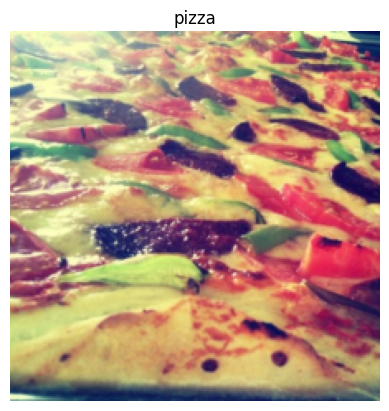

In [10]:
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis("off")

In [12]:
height = 224
width = 224
color_channels = 3
patch_size = 16
number_of_patches = int((height * width) / patch_size ** 2)
print(f"Number of patches: {number_of_patches}")

Number of patches: 196


In [14]:
embedding_layer_input_layer =  (height,width,color_channels)

embedding_layer_output_layer = (number_of_patches,patch_size**2 * color_channels)
print(f"Input shape (single 2D image): {embedding_layer_input_layer}")
print(f"Output shape (single 2D image): {embedding_layer_output_layer}")

Input shape (single 2D image): (224, 224, 3)
Output shape (single 2D image): (196, 768)


Number of patches per row : 14.0
Number of patches per column : 14.0
Total number of patches : 196.0
Patch size : 16 pixels x 16 pixels


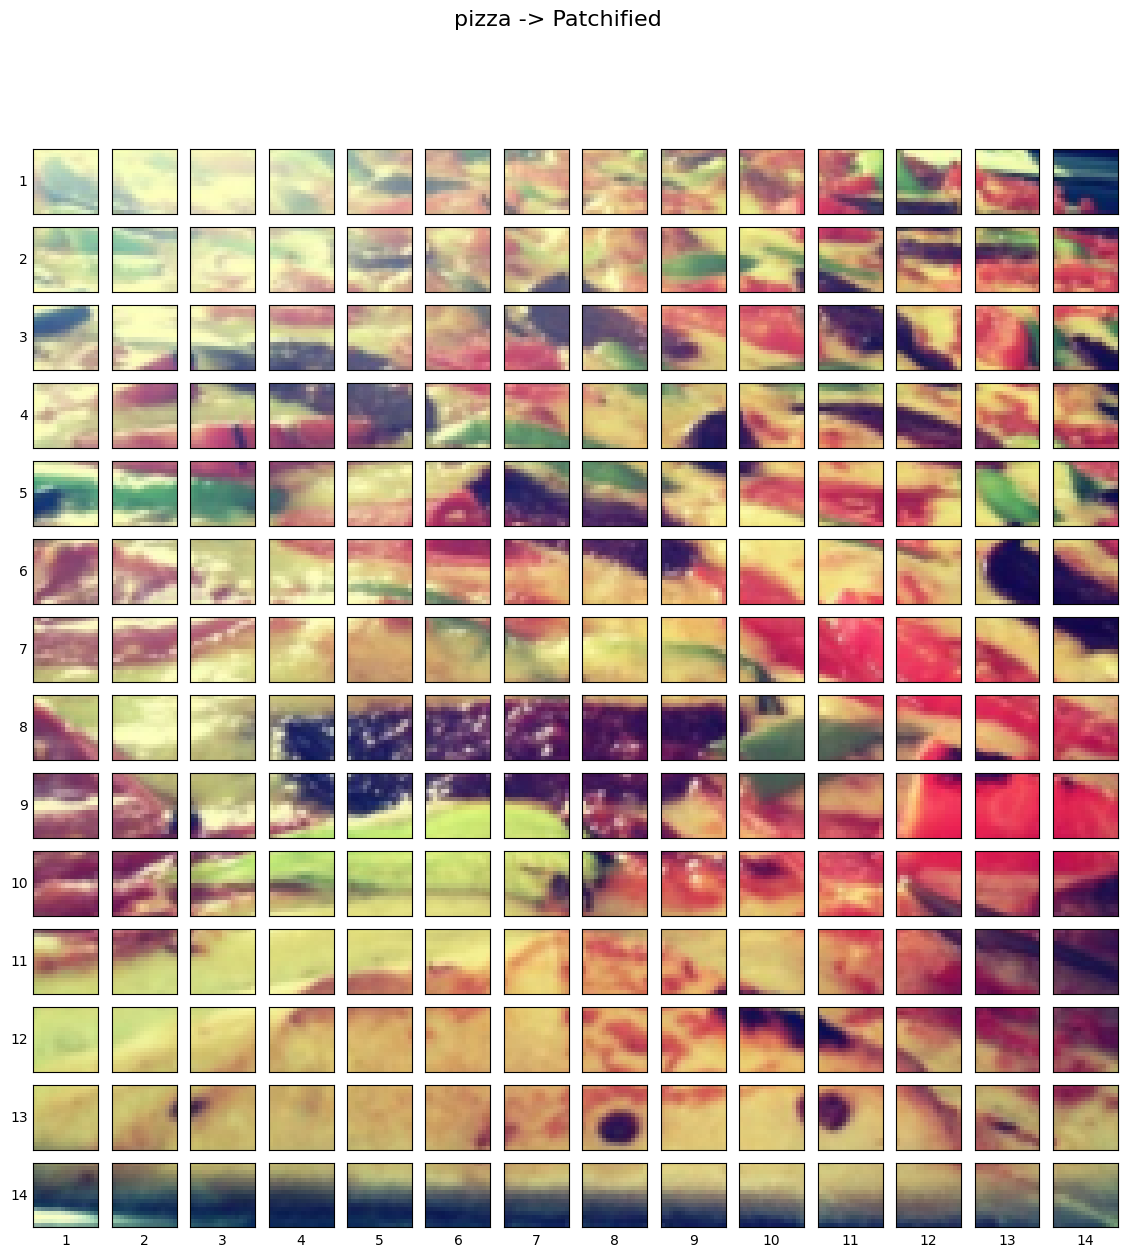

In [26]:
# patch the sample img and show patches
image_permuted = image.permute(1,2,0)
img_size = 224
patch_size = 16
num_patches = img_size / patch_size
assert img_size % patch_size == 0 ,"Image size must be divisible by the patch size"
print(f"Number of patches per row : {num_patches}\nNumber of patches per column : {num_patches}\nTotal number of patches : {num_patches*num_patches}\nPatch size : {patch_size} pixels x {patch_size} pixels")

# Create a series of subplots
fig,axs = plt.subplots(
     nrows = img_size // patch_size,
     ncols = img_size // patch_size,
     figsize = (num_patches,num_patches),
     sharex=True,
     sharey=True,
)

for i, patch_height in enumerate(range(0,img_size,patch_size)):
    for j, patch_width in enumerate(range(0,img_size, patch_size)):
        axs[i,j].imshow(image_permuted[patch_height:patch_height+patch_size,patch_width:patch_width+patch_size,:])
        axs[i,j].set_ylabel(i+1,rotation="horizontal",horizontalalignment="right",verticalalignment="center")
        axs[i,j].set_xlabel(j+1)
        axs[i,j].set_xticks([])
        axs[i,j].set_yticks([])
        axs[i,j].label_outer()

fig.suptitle(f"{class_names[label]} -> Patchified",fontsize=16)
plt.show()
